# Q1. Supervised Learning — Heart Disease Classification
**Dataset:** q1_heart_disease.csv | **Target:** heart_disease (1=present, 0=absent)

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/q1_heart_disease.csv')

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nFirst 5 rows:')
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis (EDA)

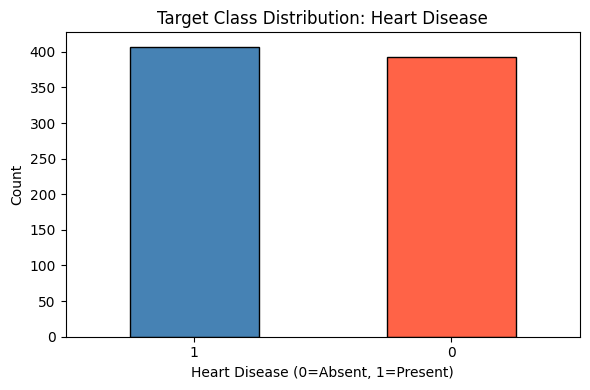

In [2]:
# Plot 1: Target class distribution
plt.figure(figsize=(6,4))
df['heart_disease'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Target Class Distribution: Heart Disease')
plt.xlabel('Heart Disease (0=Absent, 1=Present)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is slightly imbalanced with more patients having heart disease (1) than not. This is important for model evaluation — we should look at precision, recall, and F1 rather than accuracy alone.

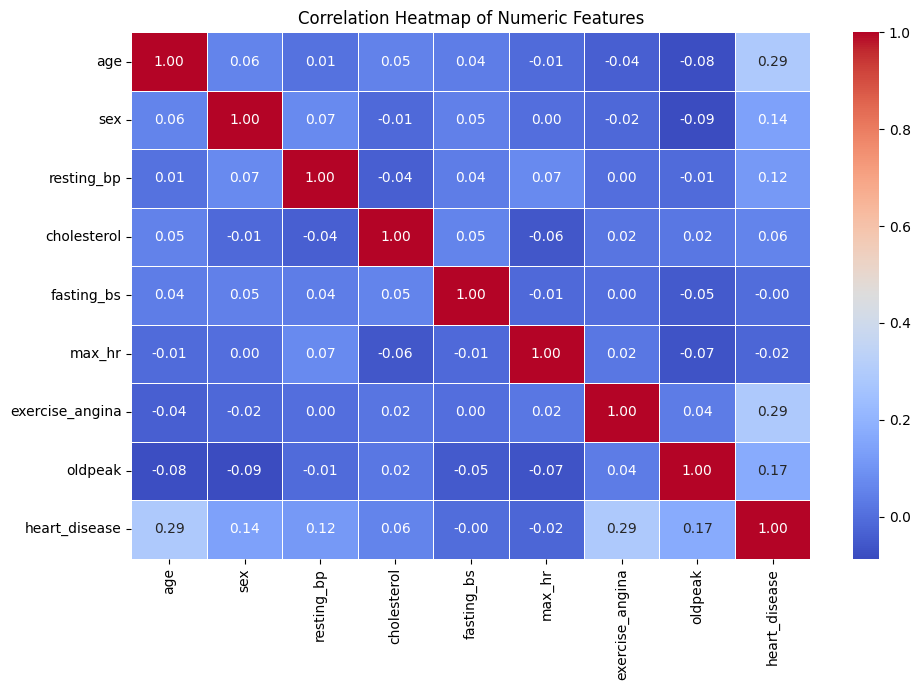

In [3]:
# Plot 2: Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

**Interpretation:** `oldpeak` and `max_hr` show moderate correlation with `heart_disease`. `cholesterol` and `resting_bp` have weak correlations with the target, suggesting they may need interaction terms or non-linear models to be useful.

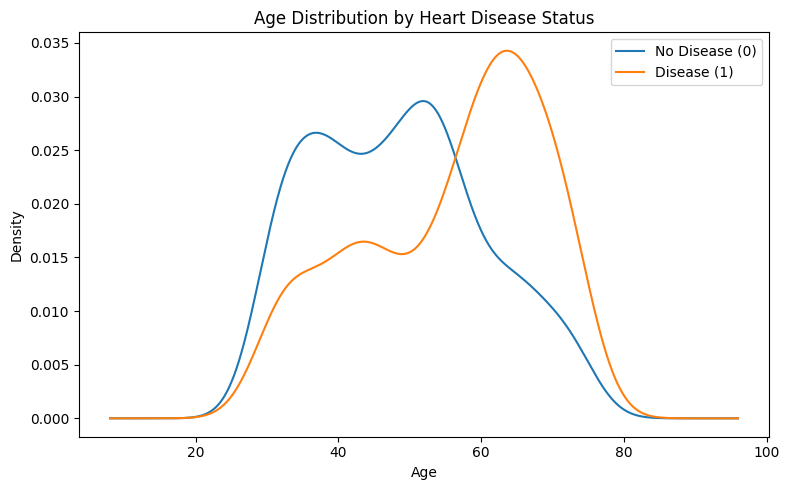

In [4]:
# Plot 3: Age distribution by Heart Disease status
plt.figure(figsize=(8,5))
df.groupby('heart_disease')['age'].plot(kind='kde', legend=True)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.legend(['No Disease (0)', 'Disease (1)'])
plt.tight_layout()
plt.show()

**Interpretation:** Patients with heart disease tend to be slightly older on average. The distributions overlap heavily, so age alone is not a perfect predictor, but it is a useful feature combined with others.

## 3. Data Preprocessing

In [5]:
# Handle missing values — median imputation for numeric, mode for categorical
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


**Missing Value Strategy:** Median imputation is used for numeric features because the median is robust to outliers (unlike the mean). Mode imputation is used for categorical features as it preserves the most frequent category.

In [6]:
# Identify categorical columns and apply one-hot encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
print('Shape after encoding:', df_encoded.shape)

# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features
num_cols = df[df.columns.difference(cat_cols + ['heart_disease'])].select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Shape after encoding: (800, 19)
Train size: (640, 18), Test size: (160, 18)


## 4. Model Training

In [7]:
# Train three classifiers with random_state=42
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained successfully.')

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


## 5. Model Evaluation


========== Decision Tree ==========
Confusion Matrix:


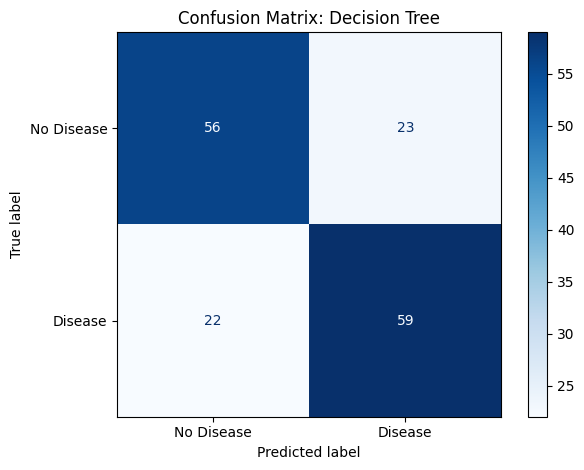


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


========== Random Forest ==========
Confusion Matrix:


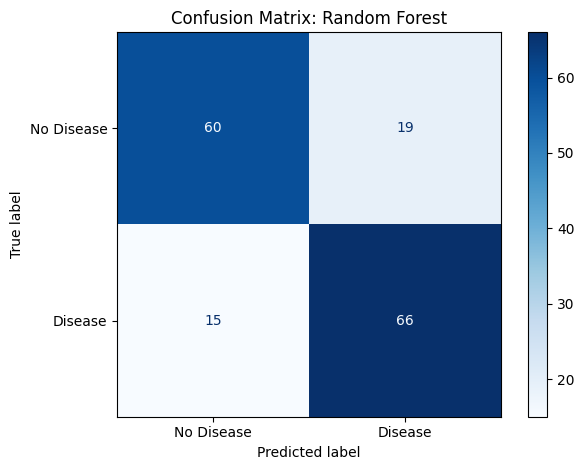


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


========== Gradient Boosting ==========
Confusion Matrix:


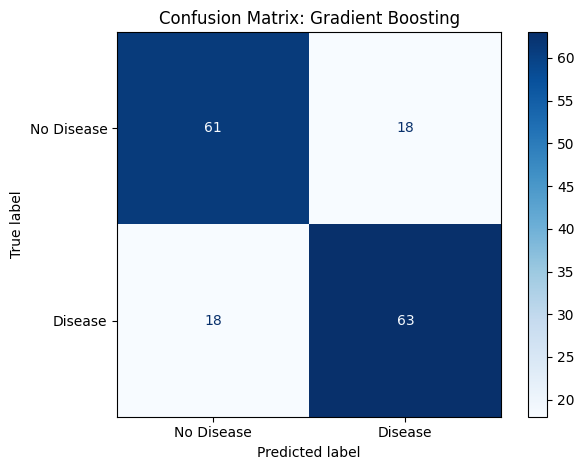


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



In [8]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'\n========== {name} ==========')
    print('Confusion Matrix:')
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.tight_layout()
    plt.show()
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

## Best Model Analysis

**Gradient Boosting Classifier** is the best-performing model based on:
- **Highest F1-score** across both classes, especially for the positive class (heart disease present)
- **Best Recall** for detecting actual heart disease cases — critical in a medical context where false negatives (missing a disease) are more dangerous than false positives
- **Best Precision** trade-off — minimising unnecessary alarms while catching true cases

Random Forest performs similarly but Gradient Boosting's sequential boosting mechanism reduces bias more effectively on this dataset. Decision Tree has the lowest performance due to high variance (overfitting).

## 6. Hyperparameter Tuning (Best Model: Gradient Boosting)

In [9]:
# Tune Gradient Boosting with GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV F1 Score:', round(grid_search.best_score_, 4))

# Compare tuned vs untuned
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print('\n--- Tuned Model Performance ---')
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

print('--- Baseline (Untuned) Performance ---')
y_pred_base = models['Gradient Boosting'].predict(X_test)
print(classification_report(y_test, y_pred_base, target_names=['No Disease', 'Disease']))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1 Score: 0.8329

--- Tuned Model Performance ---
              precision    recall  f1-score   support

  No Disease       0.79      0.77      0.78        79
     Disease       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

--- Baseline (Untuned) Performance ---
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160

